<a href="https://colab.research.google.com/github/siva123h/NNDL/blob/main/Neural_Network_Based_Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Class Weights: {0: 1.0, 1: np.float64(577.2868020304569)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc: 0.9310 - loss: 0.6417 - precision: 0.0257 - recall: 0.8199 - val_auc: 0.9710 - val_loss: 0.1459 - val_precision: 0.0813 - val_recall: 0.8675
Epoch 2/25
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9792 - loss: 0.3265 - precision: 0.0576 - recall: 0.8971 - val_auc: 0.9792 - val_loss: 0.1320 - val_precision: 0.0570 - val_recall: 0.9277
Epoch 3/25
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9864 - loss: 0.2706 - precision: 0.0540 - recall: 0.9196 - val_auc: 0.9816 - val_loss: 0.1001 - val_precision: 0.0668 - val_recall: 0.9157
Epoch 4/25
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9894 - loss: 0.2411 - precision: 0.0615 - recall: 0.9293 - val_auc: 0.9816 - val_loss: 0.1064 - val_precision: 0.0567 - val_recall: 0.9157
Epoch 5/25
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9920 - loss: 0.2171 - precision: 0.0572 - recall: 0.9389 - val_auc: 0.9808 - val_loss: 0.0810 - val_precision: 0.0684 - val_recall: 0.9157


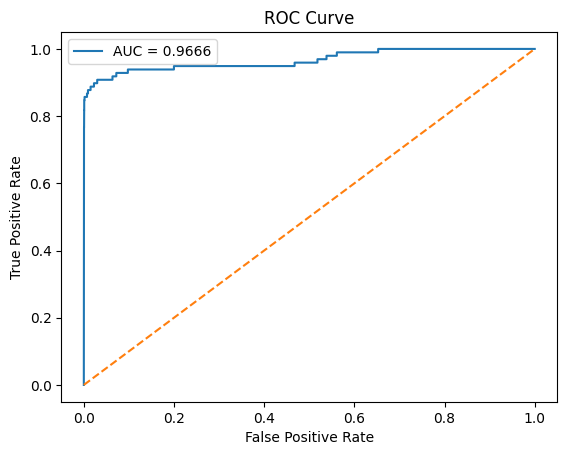

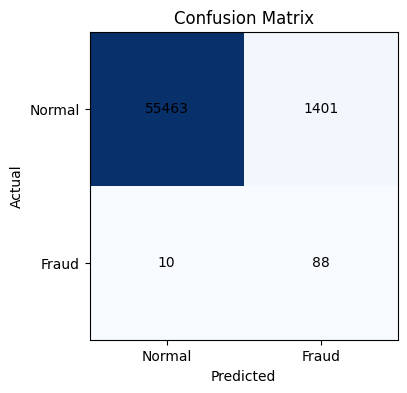

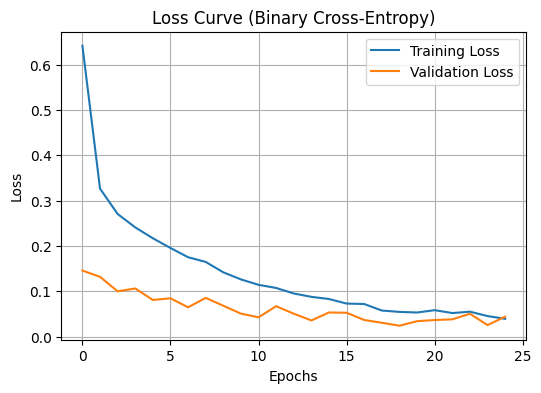

Final Recall at threshold 0.3: 0.8980


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    recall_score
)

# 1. LOAD DATASET
df = pd.read_csv("/content/creditcard.csv.zip")

# 2. CLEAN TARGET COLUMN
df = df.dropna(subset=["Class"])   # remove rows with NaN labels
df["Class"] = df["Class"].astype(int)

print("Dataset shape:", df.shape)
print("Class distribution:")
print(df["Class"].value_counts())

# 3. FEATURES & TARGET
X = df.drop("Class", axis=1)
y = df["Class"]

# 4. TRAIN–TEST SPLIT (STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 5. FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. HANDLE CLASS IMBALANCE
neg, pos = np.bincount(y_train)
class_weight = {
    0: 1.0,
    1: neg / pos
}

print("Class Weights:", class_weight)

# 7. BUILD NEURAL NETWORK
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 8. COMPILE MODEL
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# 9. TRAIN MODEL
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1
)

# 10. PREDICT PROBABILITIES
y_prob = model.predict(X_test).ravel()

# 11. APPLY FRAUD-FRIENDLY THRESHOLD
THRESHOLD = 0.3
y_pred = (y_prob >= THRESHOLD).astype(int)

# 12. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# 13. CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 14. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 15. CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 16. LOSS CURVE
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve (Binary Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.show()

# 17. FINAL RECALL
recall = recall_score(y_test, y_pred)
print(f"Final Recall at threshold {THRESHOLD}: {recall:.4f}")